In [ ]:
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torchvision import datasets, transforms


In [6]:
df = pd.read_csv('FINAL_DATASET.csv')
df.head()

,image_id,image_url,label,label_numeric,category,gender,age_group,source,fake_method,image_quality,resolution,confidence_score,detection_difficulty,dataset_split,date_collected,version,year
0,1,https://images.unsplash.com/photo-172422561835...,REAL,1,Authentic,Female,18-25,Unsplash,NaN,High,1080x1080,0.96,Easy,train,2026-04-24,v2.0,2026
1,2,https://images.unsplash.com/photo-172422561873...,REAL,1,Authentic,Male,50+,Unsplash,NaN,High,1080x1080,0.97,Easy,train,2026-04-04,v2.0,2026
2,3,https://images.unsplash.com/photo-172422561834...,REAL,1,Authentic,Female,36-50,Unsplash,NaN,High,1080x1080,0.95,Easy,test,2026-02-07,v2.0,2026
3,4,https://images.unsplash.com/photo-172422561855...,REAL,1,Authentic,Female,26-35,Unsplash,NaN,High,1080x1080,0.89,Easy,train,2026-02-20,v2.0,2026
4,5,https://images.unsplash.com/photo-172422561823...,REAL,1,Authentic,Male,36-50,Unsplash,NaN,High,1080x1080,0.86,Easy,train,2026-04-12,v2.0,2026


In [7]:
df.label.value_counts()

label
FAKE    3767
REAL    2790
Name: count, dtype: int64

In [9]:
import requests

for index, row in df.iterrows():
    url = row['image_url']
    id = row['image_id']
    label = row['label']
    response = requests.get(url)
    if response.status_code == 200:
        with open(f"images/{label}/image_{id}.jpg", 'wb') as f:
            f.write(response.content)

In [10]:
tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])
ds = datasets.ImageFolder("images/", transform=tf)   


In [16]:
train, test = torch.utils.data.random_split(ds, [0.8, 0.2])

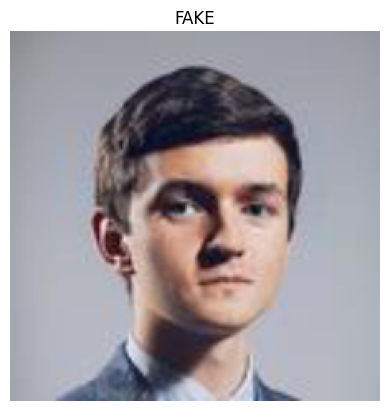

In [11]:
img, label = ds[0]
plt.imshow(img.permute(1, 2, 0))   # (C,H,W) -> (H,W,C) for matplotlib
plt.title(ds.classes[label])
plt.axis("off")
plt.show()


In [14]:
class DeepFakeDetector(nn.Module):

    def __init__(self):
        # Initialise as neural network module
        super().__init__()
        # in is 3 channels (RGB) 224x224 image, out is 3 channels (RGB) 220x220 image
        self.convolution_1 = nn.Conv2d(in_channels=3, out_channels=3, kernel_size=5)
        self.relu_1 = nn.ReLU()
        # in is 3 channels (RGB) 220x220 image, out is 3 channels (RGB) 72x72 image
        self.convolution_2 = nn.Conv2d(in_channels=3, out_channels=3, kernel_size=3, stride=3)
        self.relu_2 = nn.ReLU()
        # The input to this pooling layer is 3x72x72.
        # We pool the maximum value using a 4x4 kernel, which results in an output of 3x18x18.
        
        self.max_pooling = nn.MaxPool2d(kernel_size=4)
        # Next we flatten the output to a single dimension meaning a resulting dimension of 3x18x18 = 972 nodes
        self.flatten = nn.Flatten()
        self.linear = nn.Linear(972, 2)
        # We finally provide a softmax layer for classification
        self.softmax = nn.Softmax(dim=-1)

    def forward(self, X):
        # We receive input in the form (n_samples, height, width)
        # However, a CNN expects input in the form (n_samples, n_channels, height, width)
        # As we only have a single channel, we reshape the input by adding a one-dimensional shape at shape[1]
        # unsqueeze(<location>) reshapes a tensor by adding a one-dimensional shape at shape[<location>]
        X = self.convolution_1(X)
        X = self.relu_1(X)
        X = self.convolution_2(X)
        X = self.relu_2(X)
        X = self.max_pooling(X)
        X = self.flatten(X)
        X = self.linear(X)
        X = self.softmax(X)
        return X

In [21]:
# Imports
from torch.nn import CrossEntropyLoss
from torch.optim import Adam
from torch.utils.data import TensorDataset
from tqdm import tqdm

# Training the network
net = DeepFakeDetector()

# We use Cross Entropy Loss for this example
criterion = CrossEntropyLoss(reduction='mean')
# We use the Adam optimizer on the parameters of our network and define the learning rate (other parameters may be defined as well)
optimizer = Adam(net.parameters(), lr=0.001)

# Define how we train during an epoch
def train_single_epoch(network: nn.Module, dataset: TensorDataset) -> nn.Module:
    # Define a data loader, allowing us to shuffle data and provide a batch size
    loader = torch.utils.data.DataLoader(dataset, batch_size=32, shuffle=True)
    # Add a progress bar around dataset (optional)
    data = tqdm(loader, desc='Training')

    # Loop over data in dataset
    for X_train, y_true in data:
        # Clear any remaining tracking of gradients for backpropagation
        optimizer.zero_grad()
        # Do forward propagation by making a prediction
        y_pred = network(X_train)
        # Compute loss between predicted output and actual output
        loss = criterion(y_pred, y_true)
        # Backpropagate loss
        loss.backward()
        # Let the optimizer take a step
        optimizer.step()

    # Return the updated network
    return network

# We can train for multiple epochs
for epoch in range(50):
    net = train_single_epoch(net, train)

Training: 100%|██████████| 139/139 [01:14<00:00,  1.87it/s]


In [22]:
TP = 0
TN = 0
FP = 0
FN = 0

for img, label in test:
    with torch.no_grad():
        y_pred = net(img.unsqueeze(0))
        predicted_label = ds.classes[torch.argmax(y_pred)]
        if predicted_label == "REAL" and ds.classes[label] == "REAL":
            TP += 1
        elif predicted_label == "FAKE" and ds.classes[label] == "FAKE":
            TN += 1
        elif predicted_label == "REAL" and ds.classes[label] == "FAKE":
            FP += 1
        elif predicted_label == "FAKE" and ds.classes[label] == "REAL":
            FN += 1

print(f"True Positives: {TP}")
print(f"True Negatives: {TN}")
print(f"False Positives: {FP}")
print(f"False Negatives: {FN}")
print(f"Accuracy: {(TP + TN) / (TP + TN + FP + FN):.2f}")
print(f"Precision: {TP / (TP + FP):.2f}")
print(f"Recall: {TP / (TP + FN):.2f}")

True Positives: 570
True Negatives: 503
False Positives: 37
False Negatives: 1
Accuracy: 0.97
Precision: 0.94
Recall: 1.00


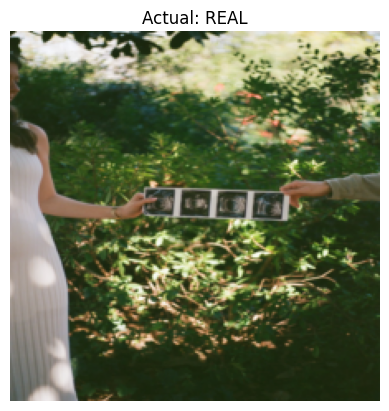

Predicted: REAL


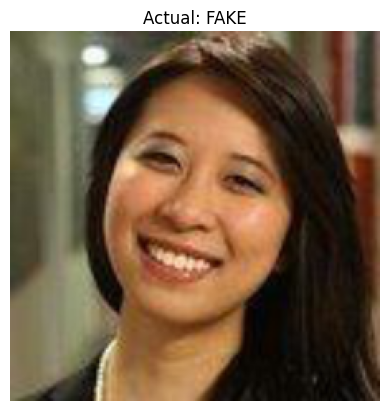

Predicted: REAL


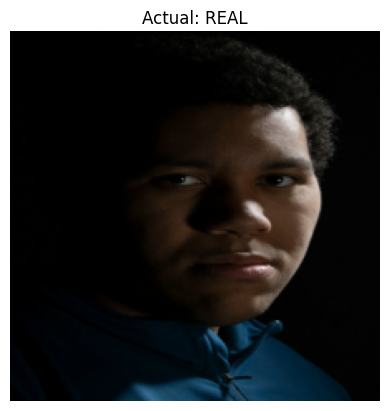

Predicted: REAL


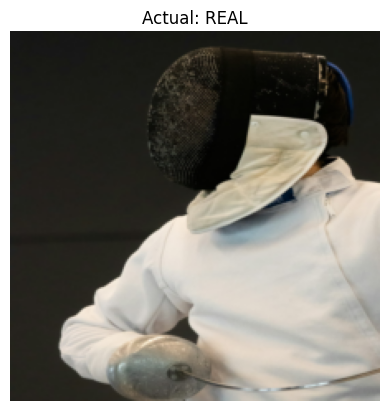

Predicted: REAL


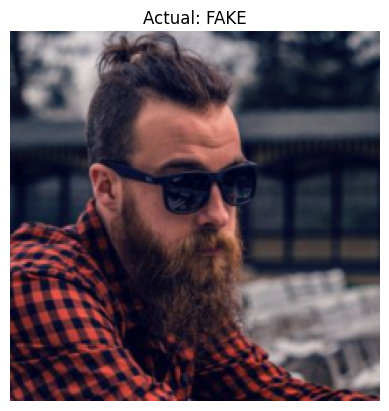

Predicted: REAL


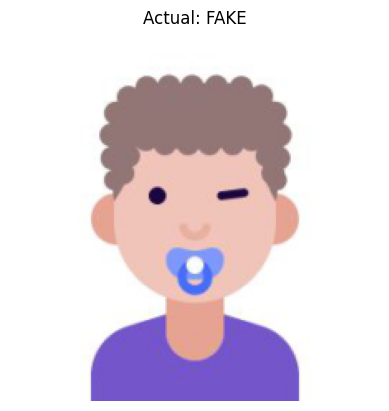

Predicted: FAKE


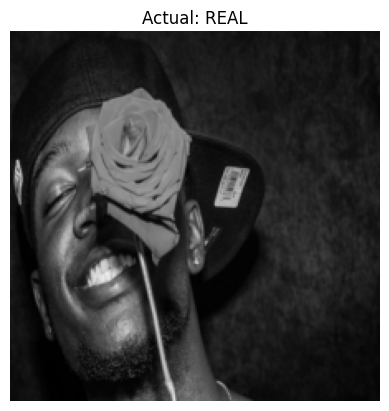

Predicted: REAL


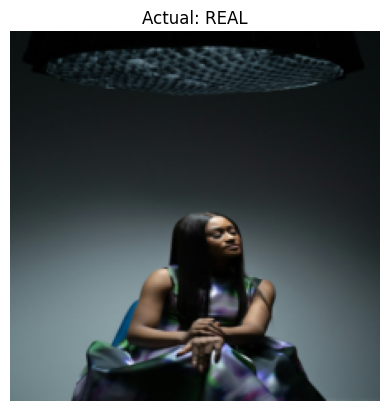

Predicted: REAL


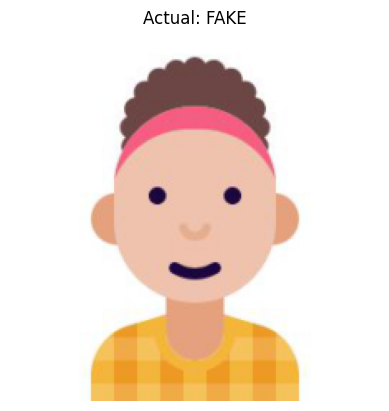

Predicted: FAKE


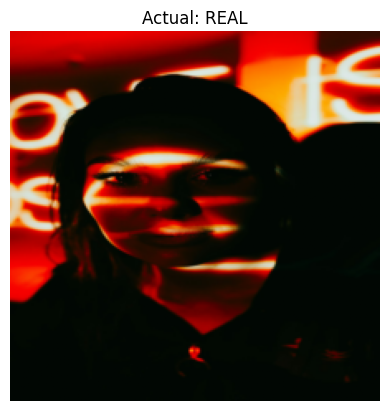

Predicted: REAL


In [24]:
for i in range(10):
    img, label = test[i]
    plt.imshow(img.permute(1, 2, 0))
    plt.title(f"Actual: {ds.classes[label]}")
    plt.axis("off")
    plt.show()
    with torch.no_grad():
        y_pred = net(img.unsqueeze(0))
        predicted_label = ds.classes[torch.argmax(y_pred)]
        print(f"Predicted: {predicted_label}")
